# Tuning MPI Parameters for the DICE Solver

In this tutorial, we explore how to optimize MPI parameters for solving SHCI at a subspace dimension of $d=10^8$ on the Miyabi-C supercomputer. This setting corresponds to the largest benchmark presented in the paper  [Chemistry Beyond the Scale of Exact Diagonalization on a Quantum-Centric Supercomputer](https://arxiv.org/abs/2405.05068), where the experiments were conducted on the Fugaku supercomputer.

Miyabi-C offers 123 GB of memory and 112 cores per node, with a maximum job size of 64 nodes. In contrast, Fugaku nodes provide 32 GB of memory and 48+2 cores. To reproduce the large-scale SHCI experiments on Miyabi-C, we must carefully tune the DICE solver to match the architecture and resource constraints of this system.

The goal of this notebook is to identify a reasonable combination of node count and `mpiprocs` value that either maximizes CPU utilization or minimizes computational cost. We begin by estimating resource usage across various configurations of subspace dimension $d$, `mpiprocs`, and node count, using the actual SQD experiment workflow.

This multi-dimensional parameter sweep is automated using the script `algorithms/sqd/scripts/tune_dice.py`.

In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def time_to_seconds(time_str: str) -> int:
    h, m, s = map(int, time_str.split(":"))
    return h * 3600 + m * 60 + s

In [2]:
artifact_data = [{"d": 10000000, "mpiprocs": 10, "nodes": 1, "energy": -326.73548452363536, "token": "0.1", "cpupercent": "996", "cput": "01:16:27", "walltime": "00:07:43", "mem": "10.78628gb", "avg_node_mem": "10.78628gb"}, {"d": 10000000, "mpiprocs": 20, "nodes": 1, "energy": -326.7354845236384, "token": "0.1", "cpupercent": "1992", "cput": "01:57:29", "walltime": "00:05:57", "mem": "15.02209gb", "avg_node_mem": "15.02209gb"}, {"d": 10000000, "mpiprocs": 30, "nodes": 1, "energy": -326.73548452363804, "token": "0.1", "cpupercent": "2984", "cput": "02:37:18", "walltime": "00:05:19", "mem": "19.32769gb", "avg_node_mem": "19.32769gb"}, {"d": 10000000, "mpiprocs": 40, "nodes": 1, "energy": -326.7354845236358, "token": "0.1", "cpupercent": "3979", "cput": "03:14:25", "walltime": "00:04:57", "mem": "23.56882gb", "avg_node_mem": "23.56882gb"}, {"d": 10000000, "mpiprocs": 50, "nodes": 1, "energy": -326.73548452363883, "token": "0.1", "cpupercent": "4965", "cput": "03:53:19", "walltime": "00:04:45", "mem": "27.91814gb", "avg_node_mem": "27.91814gb"}, {"d": 20000000, "mpiprocs": 30, "nodes": 1, "energy": -326.7356744888826, "token": "0.1", "cpupercent": "2989", "cput": "05:31:49", "walltime": "00:11:10", "mem": "35.79082gb", "avg_node_mem": "35.79082gb"}, {"d": 30000000, "mpiprocs": 30, "nodes": 1, "energy": -326.735954243741, "token": "0.3", "cpupercent": "2988", "cput": "09:23:40", "walltime": "00:18:56", "mem": "53.71087gb", "avg_node_mem": "53.71087gb"}, {"d": 40000000, "mpiprocs": 30, "nodes": 1, "energy": -326.73615751440195, "token": "0.4", "cpupercent": "2987", "cput": "13:15:31", "walltime": "00:26:48", "mem": "72.14315gb", "avg_node_mem": "72.14315gb"}, {"d": 50000000, "mpiprocs": 30, "nodes": 1, "energy": -326.73628413190085, "token": "0.5", "cpupercent": "2991", "cput": "17:44:12", "walltime": "00:35:49", "mem": "90.74546gb", "avg_node_mem": "90.74546gb"}, {"d": 50000000, "mpiprocs": 30, "nodes": 2, "energy": -326.73628413190033, "token": "0.8", "cpupercent": "5974", "cput": "30:09:01", "walltime": "00:30:25", "mem": "143.47198gb", "avg_node_mem": "71.73599gb"}, {"d": 50000000, "mpiprocs": 30, "nodes": 3, "energy": -326.73628413190005, "token": "1.0", "cpupercent": "8969", "cput": "38:50:35", "walltime": "00:26:08", "mem": "196.24454gb", "avg_node_mem": "65.41485gb"}, {"d": 50000000, "mpiprocs": 30, "nodes": 4, "energy": -326.73628413189755, "token": "1.3", "cpupercent": "11956", "cput": "49:43:01", "walltime": "00:25:06", "mem": "249.01605gb", "avg_node_mem": "62.25401gb"}, {"d": 50000000, "mpiprocs": 30, "nodes": 5, "energy": -326.73628413190124, "token": "1.6", "cpupercent": "14941", "cput": "57:35:14", "walltime": "00:23:17", "mem": "302.28234gb", "avg_node_mem": "60.45647gb"}, {"d": 100000000, "mpiprocs": 10, "nodes": 5, "energy": -326.7372353309346, "token": "5.2", "cpupercent": "4985", "cput": "64:53:42", "walltime": "01:18:14", "mem": "255.64113gb", "avg_node_mem": "51.12823gb"}]

In [3]:
df = pd.DataFrame.from_records(artifact_data); df

,d,mpiprocs,nodes,energy,token,cpupercent,cput,walltime,mem,avg_node_mem
0,10000000,10,1,-326.735485,0.1,996,01:16:27,00:07:43,10.78628gb,10.78628gb
1,10000000,20,1,-326.735485,0.1,1992,01:57:29,00:05:57,15.02209gb,15.02209gb
2,10000000,30,1,-326.735485,0.1,2984,02:37:18,00:05:19,19.32769gb,19.32769gb
3,10000000,40,1,-326.735485,0.1,3979,03:14:25,00:04:57,23.56882gb,23.56882gb
4,10000000,50,1,-326.735485,0.1,4965,03:53:19,00:04:45,27.91814gb,27.91814gb
5,20000000,30,1,-326.735674,0.1,2989,05:31:49,00:11:10,35.79082gb,35.79082gb
6,30000000,30,1,-326.735954,0.3,2988,09:23:40,00:18:56,53.71087gb,53.71087gb
7,40000000,30,1,-326.736158,0.4,2987,13:15:31,00:26:48,72.14315gb,72.14315gb
8,50000000,30,1,-326.736284,0.5,2991,17:44:12,00:35:49,90.74546gb,90.74546gb
9,50000000,30,2,-326.736284,0.8,5974,30:09:01,00:30:25,143.47198gb,71.73599gb


## `mpiprocs` (mpi per node) scaling

In [4]:
sub = df[df.d == 10000000]

Text(10, 4700, 'd=1e7, 1 node')

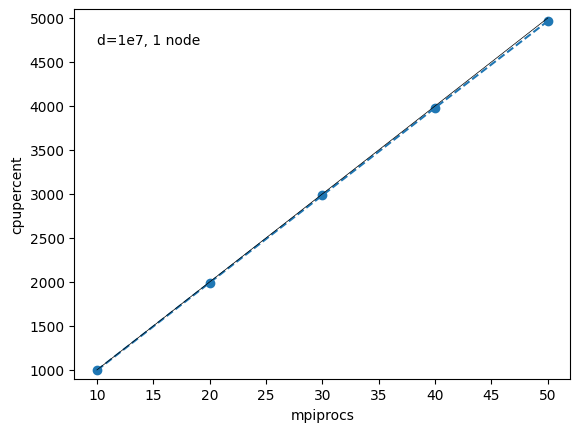

In [5]:
figure, ax = plt.subplots(1, 1)
ax.plot(sub.mpiprocs, sub.cpupercent.to_numpy(dtype=int), "o--")
ax.plot(sub.mpiprocs, sub.mpiprocs * 100, color="k", lw=0.5)
ax.set_ylim(900, 5100)
ax.set_xlabel("mpiprocs")
ax.set_ylabel("cpupercent")
ax.text(10, 4700, "d=1e7, 1 node")

Text(41, 450, 'd=1e7, 1 node')

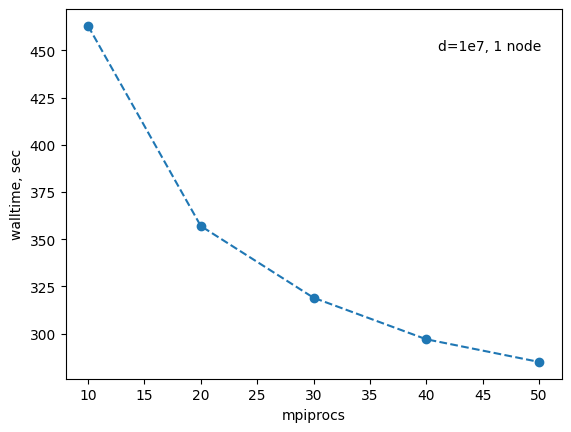

In [6]:
figure, ax = plt.subplots(1, 1)
ax.plot(sub.mpiprocs, list(map(time_to_seconds, sub.walltime.tolist())), "o--")
ax.set_xlabel("mpiprocs")
ax.set_ylabel("walltime, sec")
ax.text(41, 450, "d=1e7, 1 node")

Text(34, 20, '[0.4281045 6.481469 ]')

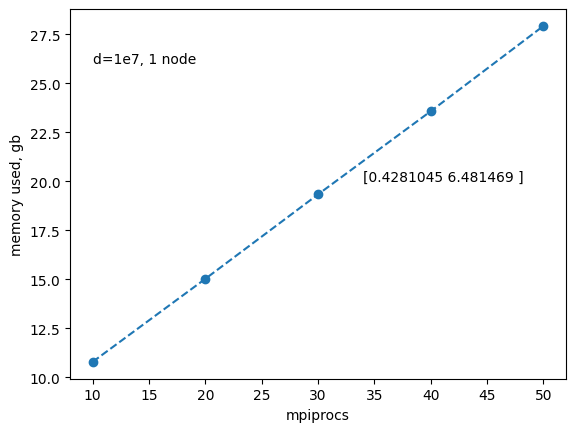

In [7]:
figure, ax = plt.subplots(1, 1)
x = sub.mpiprocs
y = list(map(lambda m: float(m[:-2]), sub.mem.tolist()))
fits_u = np.polyfit(x, y, 1)
ax.plot(x, y, "o--")
ax.set_xlabel("mpiprocs")
ax.set_ylabel("memory used, gb")
ax.text(10, 26, "d=1e7, 1 node")
ax.text(34, 20, fits_u)

## Subspace dimension $d$ scaling

In [8]:
sub = df[(df.mpiprocs == 30) & (df.nodes == 1)]

Text(1, 4700, 'mpiprocs=30, 1 node')

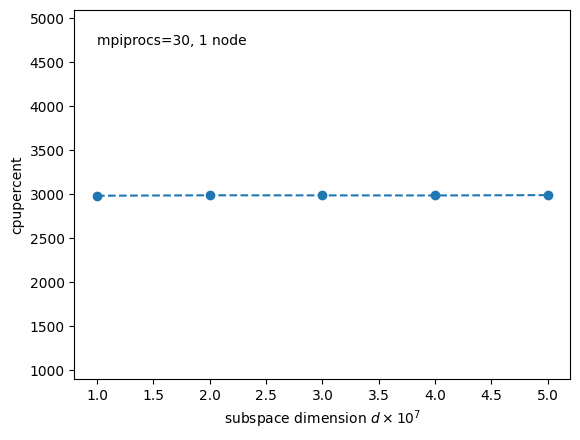

In [9]:
figure, ax = plt.subplots(1, 1)
ax.plot(sub.d / 1e7, sub.cpupercent.to_numpy(dtype=int), "o--")
ax.set_ylim(900, 5100)
ax.set_xlabel(r"subspace dimension $d \times 10^7$")
ax.set_ylabel("cpupercent")
ax.text(1, 4700, "mpiprocs=30, 1 node")

Text(1, 2000, 'mpiprocs=30, 1 node')

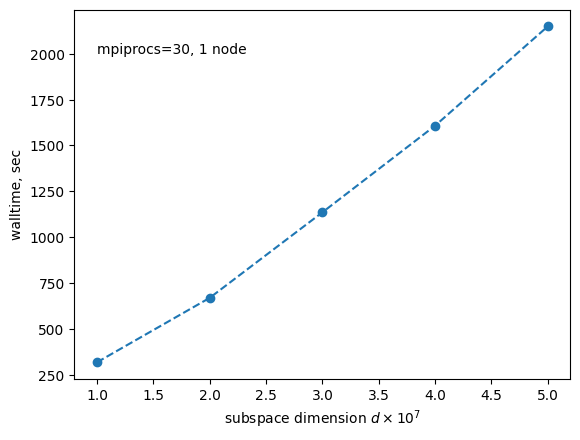

In [10]:
figure, ax = plt.subplots(1, 1)
ax.plot(sub.d / 1e7, list(map(time_to_seconds, sub.walltime.tolist())), "o--")
ax.set_xlabel(r"subspace dimension $d \times 10^7$")
ax.set_ylabel("walltime, sec")
ax.text(1, 2000, "mpiprocs=30, 1 node")

Text(3.3, 53, '[17.918787  0.587237]')

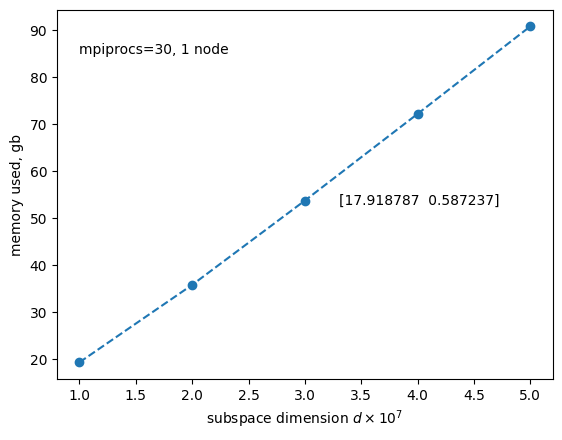

In [11]:
figure, ax = plt.subplots(1, 1)
x = sub.d / 1e7
y = list(map(lambda m: float(m[:-2]), sub.mem.tolist()))
fits_v = np.polyfit(x, y, 1)
ax.plot(x, y, "o--")
ax.set_xlabel(r"subspace dimension $d \times 10^7$")
ax.set_ylabel("memory used, gb")
ax.text(1, 85, "mpiprocs=30, 1 node")
ax.text(3.3, 53, fits_v)

## Node number scaling

In [12]:
sub = df[(df.d == 50000000) & (df.mpiprocs == 30)]

Text(1, 14000, 'd=5e7, mpiprocs=30')

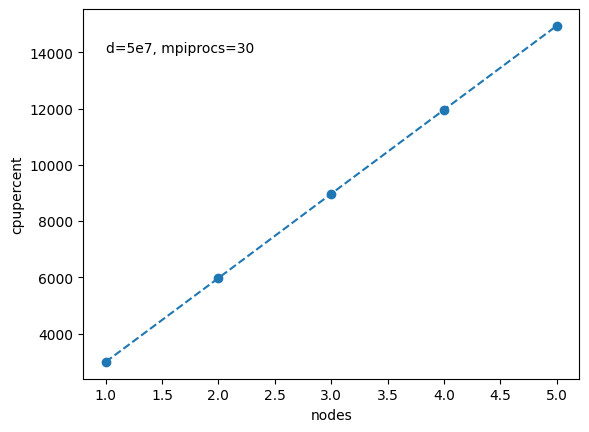

In [13]:
figure, ax = plt.subplots(1, 1)
ax.plot(sub.nodes, sub.cpupercent.to_numpy(dtype=int), "o--")
ax.set_xlabel("nodes")
ax.set_ylabel("cpupercent")
ax.text(1, 14000, "d=5e7, mpiprocs=30")

Text(3.6, 2100, 'd=5e7, mpiprocs=30')

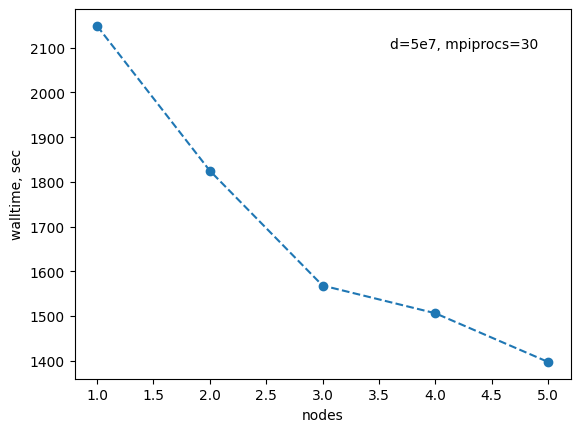

In [14]:
figure, ax = plt.subplots(1, 1)
ax.plot(sub.nodes, list(map(time_to_seconds, sub.walltime.tolist())), "o--")
ax.set_xlabel("nodes")
ax.set_ylabel("walltime, sec")
ax.text(3.6, 2100, "d=5e7, mpiprocs=30")

Text(3, 180, '[52.861783 37.766725]')

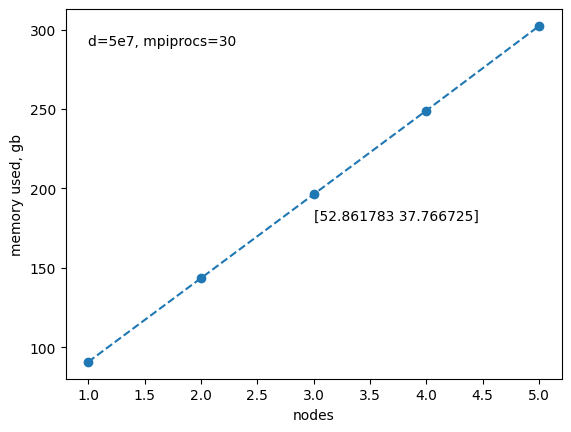

In [15]:
figure, ax = plt.subplots(1, 1)
x = sub.nodes
y = list(map(lambda m: float(m[:-2]), sub.mem.tolist()))
fits_n = np.polyfit(x, y, 1)
ax.plot(x, y, "o--")
ax.set_xlabel("nodes")
ax.set_ylabel("memory used, gb")
ax.text(1, 290, "d=5e7, mpiprocs=30")
ax.text(3, 180, fits_n)

30 mpiprocs per node:

In [16]:
fits_n[0] / 30

np.float64(1.7620594333333333)

# Modeling Memory Usage

We assume that the total memory usage follows a bilinear model:

$F(u, v) = c_0 + c_1 u + c_2 v + c_3 uv$

where:
- $u$ is the number of `mpiprocs`,
- $v$ is the subspace dimension normalized by $10^7$.

This model is a reasonable choice because memory usage scales with both `mpiprocs` and the subspace dimension. Additionally, the memory usage per process is not constant—it increases with the subspace dimension. This is due to the fact that the size of state vectors loaded into each rank's memory is proportional to the subspace dimension.

By fitting this model to empirical data, we can estimate the coefficients $( c_0, c_1, c_2, c_3 )$ and predict memory usage for arbitrary configurations of `mpiprocs` and subspace dimension.


From the experiments:
- $F(u_0, v) = a_1 v + a_0$; $u_0 = 30$
- $F(u, v_0) = b_1 u + b_0$; $v_0 = 1$

This yields in terms of $c_3$:
- $c_1 = b_1 - c_3 v_0$
- $c_2 = a_1 - c_3 u_0$

Intercept must satisfy:

- $L = a_0 - b_1 u_0 + c_3 u_0 v_0$
- $R = b_0 - a_1 v_0 + c_3 u_0 v_0$
- $L = R$

If we have an additional measurement $(u_1, v_1)$:

- $y_1 = F(u_1, v_1) = L + (b_1 - c_3 v_0) u_1 + (a_1 - c_3 u_0) v_1 + c_3 u_1 v_1$

This yields:

- $c_3 = \dfrac{y_1 - a_0 - a_1 v_1 + (u_0 - u_1) b_1}{(u_0 - u_1) (v_0 - v_1)}$

We can use the last data point:

- $y_1 = 255.64113$gb
- $u_1 = 10 \times 5$ (nodes) procs
- $v_1 = 10$ (1e7d)

In [17]:
a1, a0 = fits_v
b1, b0 = fits_u
u0 = 30
v0 = 1
u1 = 50
v1 = 10
y1 = 255.64113

In [18]:
c3 = (y1 - a0 - a1 * v1 + (u0 - u1) * b1) / ((u0 - u1) * (v0 - v1))
c2 = a1 - c3 * u0
c1 = b1 - c3 * v0
L = a0 - b1 * u0 + c3 * u0 * v0
R = b0 - a1 * v0 + c3 * u0 * v0

In [19]:
L, R

(np.float64(-1.038575833333372), np.float64(-0.21999583333333916))

In [20]:
c0 = np.average([L, R]); c0

np.float64(-0.6292858333333555)

In [21]:
mem_model = lambda u, v: c0 + c1 * u + c2 * v + c3 * u * v

## Testing with the node scaling result

Text(1, 290, 'd=5e7, mpiprocs=30')

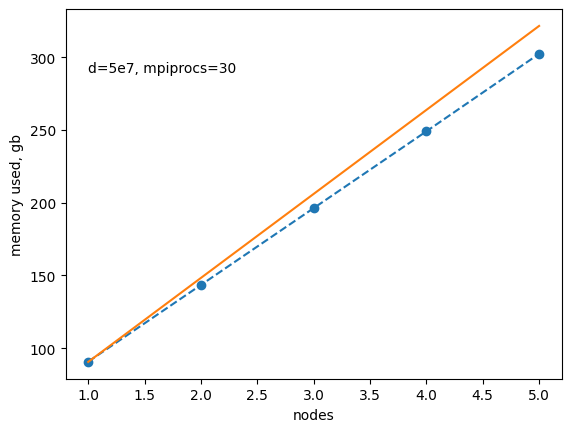

In [22]:
sub = df[(df.d == 50000000) & (df.mpiprocs == 30)]

figure, ax = plt.subplots(1, 1)
x = sub.nodes
y = list(map(lambda m: float(m[:-2]), sub.mem.tolist()))

total_procs = 30 * x
y_ = mem_model(total_procs, 5)
ax.plot(x, y, "o--")
ax.plot(x, y_)
ax.set_xlabel("nodes")
ax.set_ylabel("memory used, gb")
ax.text(1, 290, "d=5e7, mpiprocs=30")

This model roughly agrees with actual memory consumption.

## Estimating the `mpiprocs` and node numbers for $d=10^8$

Constraints:
- per node memory < 123731968kb
- per node mpiprocs < 112
- node with rank0 consumes more memory, so we need safety mergin

Assumption:
- cpupercent (utilization) is linear against nodes

In [23]:
cpuct = 122
cpu_utilizations = np.linspace(0.1, 0.9, 9)
max_mem = 123.731968
mem_mergin = 0.8

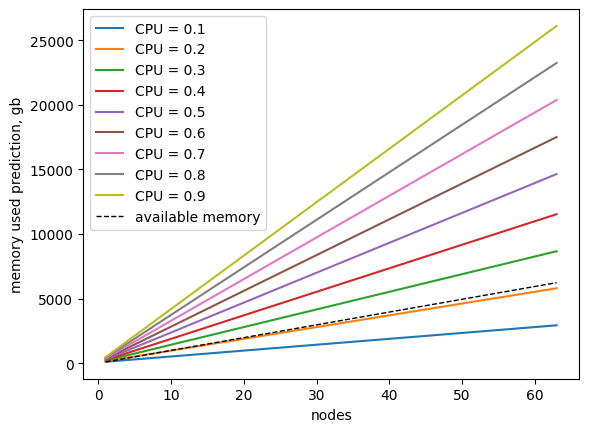

In [24]:
figure, ax = plt.subplots(1, 1)

nodes = np.arange(1, 64)
mem_avail = max_mem * mem_mergin * nodes

for cpu_utilization in cpu_utilizations:
    target = int(cpuct * cpu_utilization)
    net_procs = target * nodes
    mem_pred = mem_model(net_procs, 10)
    ax.plot(nodes, mem_pred, label=f"CPU = {cpu_utilization:.1f}")

ax.plot(nodes, mem_avail, "--", color="k", lw=1, label="available memory")
ax.set_xlabel("nodes")
ax.set_ylabel("memory used prediction, gb")
ax.legend()

As shown in the profiling results, we are able to utilize only about 20% of the available CPU cores. This low utilization highlights a key challenge: improving CPU efficiency through techniques such as sparse matrix optimization is difficult, especially on Miyabi-C.

The architecture of Miyabi-C—with a large number of CPU cores per node—makes it particularly hard to scale workloads efficiently. Many scientific applications, including SHCI, are memory-bound or communication-bound, and do not naturally scale to fully exploit all cores on such nodes. This underscores the importance of tuning both algorithmic parameters and MPI configurations to achieve better performance.

# Compute Cost Estimate

From our previous investigation, we confirmed that increasing CPU utilization is challenging for applications like sparse matrix diagonalization. This means that adding more compute nodes often results in a higher number of idle cores, with only marginal improvements in wall-clock time.

To optimize for compute cost rather than CPU utilization, we evaluate the trade-off between wall-clock time reduction and token consumption at a fixed subspace dimension size. In this experiment, we run the DICE solver at $d = 10^8$ using different numbers of compute nodes. Based on our memory consumption prediction model, we assume a CPU availability of approximately 20% (`mpiprocs` = 20).

In [25]:
artifact_data = [{"d": 100000000, "mpiprocs": 10, "nodes": 1, "energy": None, "token": "1.2", "cpupercent": "997", "cput": "15:05:29", "walltime": "01:31:02", "mem": "105.24447gb", "avg_node_mem": "105.24447gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 5, "energy": -326.73712777723676, "token": "5.5", "cpupercent": "9968", "cput": "136:06:49", "walltime": "01:22:15", "mem": "418.82135gb", "avg_node_mem": "83.76427gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 10, "energy": -326.7371277772355, "token": "7.1", "cpupercent": "19934", "cput": "174:55:08", "walltime": "00:52:54", "mem": "770.36361gb", "avg_node_mem": "77.03636gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 20, "energy": -326.73712777723756, "token": "13.1", "cpupercent": "39859", "cput": "324:44:15", "walltime": "00:49:07", "mem": "1439.47564gb", "avg_node_mem": "71.97378gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 30, "energy": -326.7371277772369, "token": "22.1", "cpupercent": "59782", "cput": "548:55:42", "walltime": "00:55:22", "mem": "2119.51501gb", "avg_node_mem": "70.65050gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 40, "energy": -326.737127777235, "token": "26.2", "cpupercent": "79704", "cput": "648:52:22", "walltime": "00:49:05", "mem": "2793.52496gb", "avg_node_mem": "69.83812gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 50, "energy": -326.7371277772356, "token": "30.7", "cpupercent": "99635", "cput": "761:42:01", "walltime": "00:46:07", "mem": "3471.22083gb", "avg_node_mem": "69.42442gb"}, {"d": 100000000, "mpiprocs": 20, "nodes": 64, "energy": -326.73712777723665, "token": "37.6", "cpupercent": "127521", "cput": "931:08:30", "walltime": "00:44:03", "mem": "4421.35845gb", "avg_node_mem": "69.08372gb"}]

In [26]:
df = pd.DataFrame.from_records(artifact_data); df

,d,mpiprocs,nodes,energy,token,cpupercent,cput,walltime,mem,avg_node_mem
0,100000000,10,1,NaN,1.2,997,15:05:29,01:31:02,105.24447gb,105.24447gb
1,100000000,20,5,-326.737128,5.5,9968,136:06:49,01:22:15,418.82135gb,83.76427gb
2,100000000,20,10,-326.737128,7.1,19934,174:55:08,00:52:54,770.36361gb,77.03636gb
3,100000000,20,20,-326.737128,13.1,39859,324:44:15,00:49:07,1439.47564gb,71.97378gb
4,100000000,20,30,-326.737128,22.1,59782,548:55:42,00:55:22,2119.51501gb,70.65050gb
5,100000000,20,40,-326.737128,26.2,79704,648:52:22,00:49:05,2793.52496gb,69.83812gb
6,100000000,20,50,-326.737128,30.7,99635,761:42:01,00:46:07,3471.22083gb,69.42442gb
7,100000000,20,64,-326.737128,37.6,127521,931:08:30,00:44:03,4421.35845gb,69.08372gb


Text(43, 5300, 'd=1e8, mpiprocs=20')

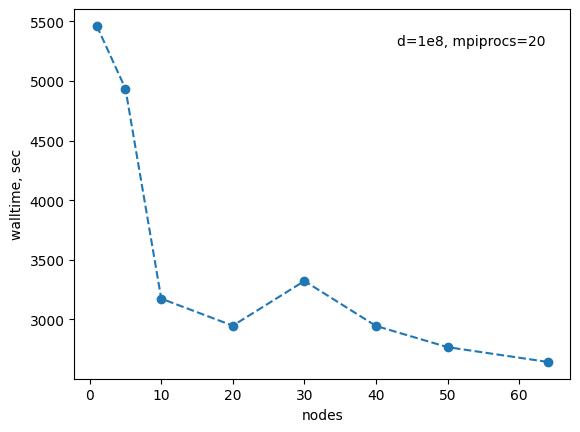

In [27]:
figure, ax = plt.subplots(1, 1)
ax.plot(df.nodes, list(map(time_to_seconds, df.walltime.tolist())), "o--")
ax.set_xlabel("nodes")
ax.set_ylabel("walltime, sec")
ax.text(43, 5300, "d=1e8, mpiprocs=20")

Text(2, 35, 'd=1e8, mpiprocs=20')

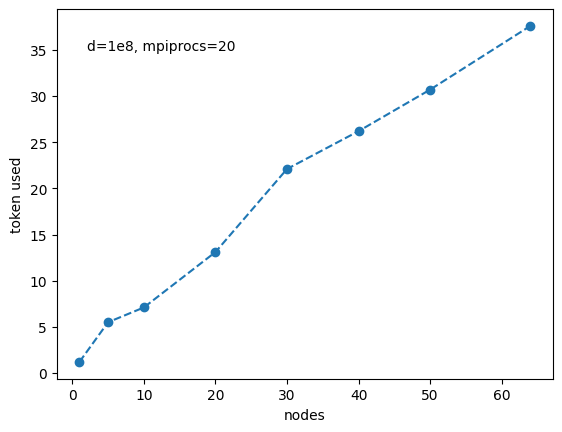

In [28]:
figure, ax = plt.subplots(1, 1)
ax.plot(df.nodes, df.token.to_numpy(dtype=float), "o--")
ax.set_xlabel("nodes")
ax.set_ylabel("token used")
ax.text(2, 35, "d=1e8, mpiprocs=20")

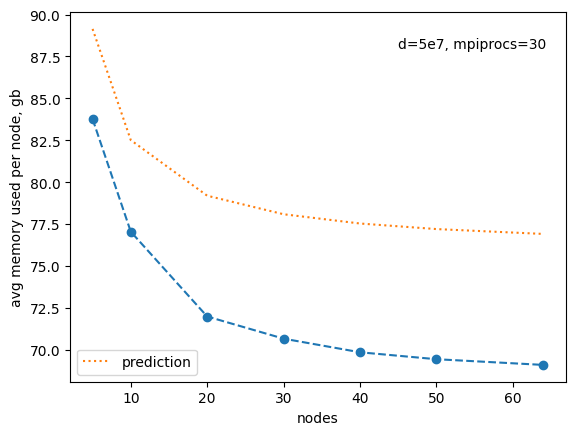

In [29]:
figure, ax = plt.subplots(1, 1)
x = df.nodes[1:]
y = list(map(lambda m: float(m[:-2]), df.avg_node_mem.tolist()))[1:]
ax.plot(x, y, "o--")
ax.set_xlabel("nodes")
ax.set_ylabel("avg memory used per node, gb")
ax.text(45, 88, "d=5e7, mpiprocs=30")

ax.plot(x, mem_model(x*20, 10) / x, ":", label="prediction")
ax.legend(loc="lower left")

The results show that:
- Token consumption increases roughly linearly with the number of nodes.
- Wall-clock time saturates around 10 nodes.
- Actual memory usage is approximately 10 GB lower than predicted.

This suggests that we could add a few more MPI processes per node, but doing so would not significantly reduce the wall-clock time. 

**Conclusion:**  
Using 10 compute nodes with `mpiprocs` between 10 and 20 is optimal for solving SHCI at $d = 10^8$. However, if wall-clock time is not a critical factor in your workflow, using fewer nodes can help conserve tokens.

In [30]:
mpiprocs = 27
nodes = 10

mem_model(mpiprocs*nodes, 10) / nodes

np.float64(109.05766730000002)